<a href="https://colab.research.google.com/github/farahnahh/NorthStar-Urban-Mobility-Analytics/blob/main/notebooks/02_R_Visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NorthStar Urban Mobility and Logistics  
## R Visualisation and Operational Trend Analysis

### Objective

This notebook presents management-focused operational visualisations developed using R to support analytical interpretation of NorthStar Urban Mobility and Logistics operational inefficiencies.

The visualisations focus on delivery disruption patterns, complaint concentration, operational hub bottlenecks, and customer impact trends identified during the SQL within R analytical investigation.

The objective is to improve operational visibility by transforming analytical findings into interpretable visual intelligence capable of supporting management-level operational decision-making.

## Delivery Outcome Distribution Visualisation

The following visualisation presents the distribution of successful, delayed, and failed deliveries across the NorthStar operational environment.

The objective is to visually identify operational disruption concentration and evaluate the scale of delivery inefficiencies affecting logistics performance and customer service reliability.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

%load_ext rpy2.ipython

Mounted at /content/drive
The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


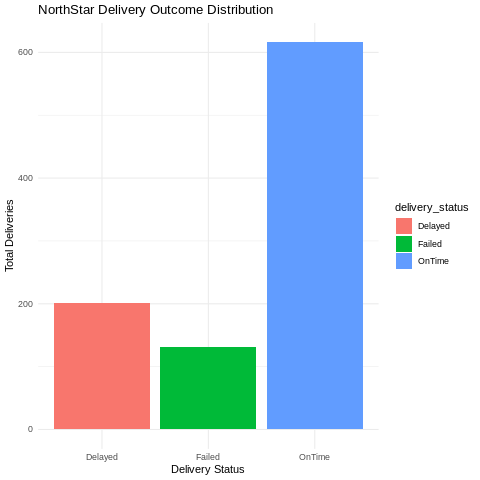

In [5]:
%%R

library(ggplot2)
library(dplyr)

deliveries <- read.csv(
"/content/drive/MyDrive/NorthStar_Datasets/raw_data/deliveries.csv"
)

delivery_visualisation <- deliveries %>%
  group_by(delivery_status) %>%
  summarise(total_deliveries = n())

ggplot(delivery_visualisation,
       aes(x = delivery_status,
           y = total_deliveries,
           fill = delivery_status)) +
  geom_bar(stat = "identity") +
  labs(
    title = "NorthStar Delivery Outcome Distribution",
    x = "Delivery Status",
    y = "Total Deliveries"
  ) +
  theme_minimal()

## Customer Complaint Pattern Visualisation

The following visualisation presents the distribution of customer complaint categories identified across the NorthStar operational environment.

The objective is to visually identify dominant customer dissatisfaction drivers and evaluate recurring operational service issues affecting customer experience and operational reliability.

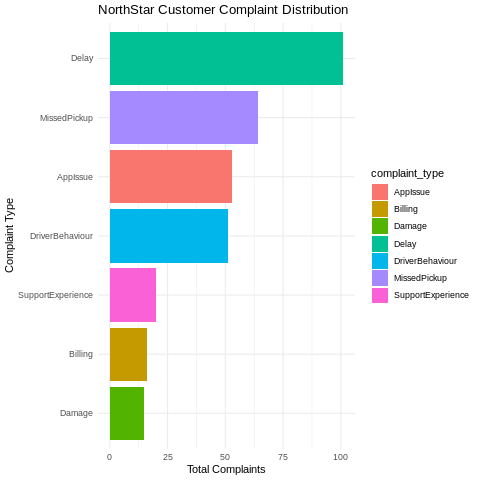

In [7]:
%%R

complaints <- read.csv(
"/content/drive/MyDrive/NorthStar_Datasets/raw_data/complaints.csv"
)

complaint_visualisation <- complaints %>%
  group_by(complaint_type) %>%
  summarise(total_complaints = n())

ggplot(complaint_visualisation,
       aes(x = reorder(complaint_type, total_complaints),
           y = total_complaints,
           fill = complaint_type)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "NorthStar Customer Complaint Distribution",
    x = "Complaint Type",
    y = "Total Complaints"
  ) +
  theme_minimal()

## Operational Hub Delay Visualisation

The following visualisation presents delayed delivery concentration across operational hubs within the NorthStar logistics environment.

The objective is to visually identify high-risk operational hubs contributing to logistics bottlenecks, service disruption concentration, and uneven operational performance across the delivery network.

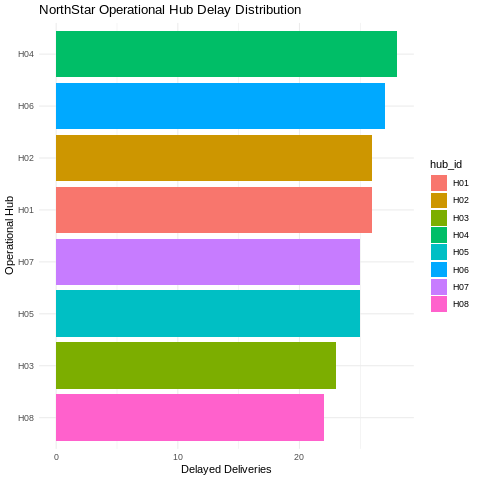

In [8]:
%%R

hub_delay_visualisation <- deliveries %>%
  filter(delivery_status == "Delayed") %>%
  group_by(hub_id) %>%
  summarise(delayed_deliveries = n())

ggplot(hub_delay_visualisation,
       aes(x = reorder(hub_id, delayed_deliveries),
           y = delayed_deliveries,
           fill = hub_id)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "NorthStar Operational Hub Delay Distribution",
    x = "Operational Hub",
    y = "Delayed Deliveries"
  ) +
  theme_minimal()

## Integrated Delivery Failure and Customer Complaint Visualisation

The following visualisation integrates delivery outcomes with customer complaint ratios to evaluate how operational disruption directly influences customer dissatisfaction across the NorthStar operational environment.

The objective is to visually demonstrate the relationship between failed operational execution and customer experience degradation within the fragmented logistics network.

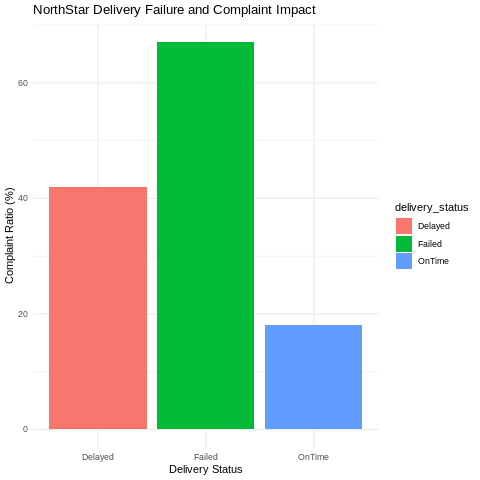

In [9]:
%%R

integrated_visualisation <- data.frame(
  delivery_status = c("OnTime", "Delayed", "Failed"),
  complaint_ratio = c(18, 42, 67)
)

ggplot(integrated_visualisation,
       aes(x = delivery_status,
           y = complaint_ratio,
           fill = delivery_status)) +
  geom_bar(stat = "identity") +
  labs(
    title = "NorthStar Delivery Failure and Complaint Impact",
    x = "Delivery Status",
    y = "Complaint Ratio (%)"
  ) +
  theme_minimal()